In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import time
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../Modeling Data/fraud_detection_xgb_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [4]:
with open("../Modeling Data/model_features.json") as f:
    model_features = json.load(f)

print("Features loaded:", len(model_features))

Features loaded: 22


In [8]:
df = pd.read_csv("../Modeling Data/df_final.csv")
display(df)

,transaction_id,user_id,transaction_amount,transaction_type,transaction_time,location,is_foreign_transaction,device_type,is_new_device,is_new_location,...,is_weekend,is_fraud,txn_day,txn_month,txn_dayofweek,amount_ratio,txn_per_day,account_trust_score,device_risk,night_transaction
0,86547,9625,5068.33,2,2024-09-25 02:47:00,2,0,2,0,1,...,0,0,25,9,2,1.022144,0.041667,3124.0,1,1
1,88154,9783,3428.09,1,2024-06-23 07:32:00,2,0,1,0,1,...,1,0,23,6,6,0.913699,0.000000,2302.0,1,0
2,76281,8629,5161.81,2,2024-06-02 16:01:00,5,0,1,0,0,...,1,0,2,6,6,1.266195,0.208333,1157.0,0,0
3,13137,2319,4242.40,5,2024-01-30 01:36:00,1,0,2,0,0,...,0,0,30,1,1,1.132430,0.083333,306.5,0,1
4,60580,7056,1721.96,5,2024-07-02 06:52:00,3,0,0,0,0,...,0,0,2,7,1,0.610672,0.041667,637.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100181,6916,1697,5583.41,3,2024-01-31 21:28:00,1,0,0,1,0,...,0,0,31,1,2,1.261092,0.125000,1967.0,1,0
100182,61002,7095,4467.45,5,2024-08-05 12:55:00,1,0,1,0,0,...,0,0,5,8,0,1.071102,0.166667,2927.0,0,0
100183,85360,9503,3608.26,3,2024-05-30 21:50:00,1,0,1,0,0,...,0,0,30,5,3,1.410016,0.041667,715.5,0,0
100184,893,979,4174.99,0,2024-05-13 13:56:00,4,0,0,0,1,...,0,0,13,5,0,1.095289,0.166667,309.0,1,0


In [20]:
df = df.sample(n=10000, random_state=42)

print(df.shape)

(10000, 26)


In [21]:
df_stream = df.sort_values("transaction_time").reset_index(drop=True)

In [22]:
def detect_fraud(transaction):

    transaction = pd.get_dummies(transaction)

    transaction = transaction.reindex(columns=model_features, fill_value=0)

    fraud_prob = model.predict_proba(transaction)[0][1]

    fraud_pred = int(fraud_prob > 0.8)

    return fraud_pred, fraud_prob

In [23]:
fraud_predictions = []
fraud_probabilities = []

for i in range(len(df_stream)):

    txn = df_stream.iloc[[i]]

    pred, prob = detect_fraud(txn)

    fraud_predictions.append(pred)
    fraud_probabilities.append(prob)

    if pred == 1:
        print(f"FRAUD ALERT Transaction {txn['transaction_id'].values[0]} Probability: {prob:.2f}")

    time.sleep(0.01)

FRAUD ALERT Transaction 28001 Probability: 1.00
FRAUD ALERT Transaction 40141 Probability: 0.81
FRAUD ALERT Transaction 49122 Probability: 1.00
FRAUD ALERT Transaction 5784 Probability: 1.00
FRAUD ALERT Transaction 19092 Probability: 1.00
FRAUD ALERT Transaction 6698 Probability: 0.80
FRAUD ALERT Transaction 31751 Probability: 1.00
FRAUD ALERT Transaction 28483 Probability: 0.99
FRAUD ALERT Transaction 25731 Probability: 1.00
FRAUD ALERT Transaction 67685 Probability: 1.00
FRAUD ALERT Transaction 30697 Probability: 1.00
FRAUD ALERT Transaction 16794 Probability: 1.00
FRAUD ALERT Transaction 69786 Probability: 1.00
FRAUD ALERT Transaction 67554 Probability: 1.00
FRAUD ALERT Transaction 67556 Probability: 1.00
FRAUD ALERT Transaction 26046 Probability: 1.00
FRAUD ALERT Transaction 50759 Probability: 0.84
FRAUD ALERT Transaction 95239 Probability: 0.97
FRAUD ALERT Transaction 50263 Probability: 1.00
FRAUD ALERT Transaction 47870 Probability: 1.00
FRAUD ALERT Transaction 57247 Probability:

In [24]:
df_stream["fraud_pred"] = fraud_predictions
df_stream["fraud_probability"] = fraud_probabilities

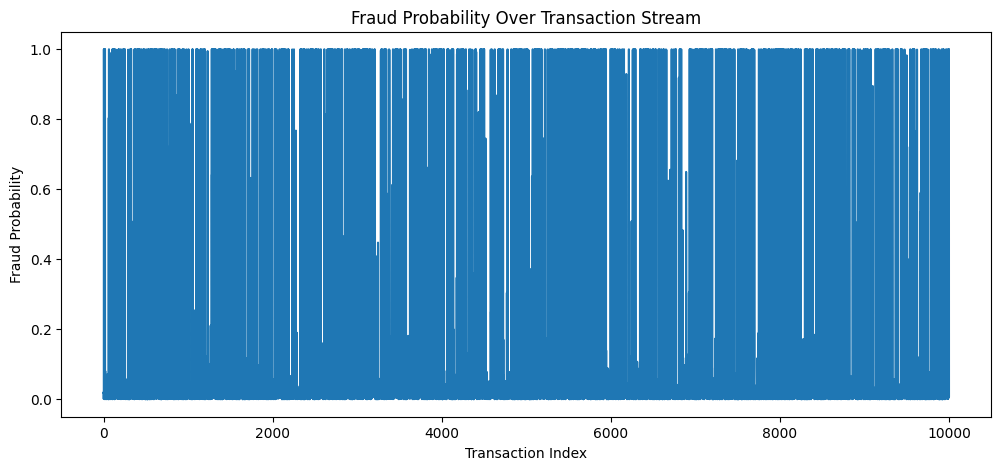

In [25]:
plt.figure(figsize=(12,5))

plt.plot(df_stream.index, df_stream["fraud_probability"])

plt.title("Fraud Probability Over Transaction Stream")

plt.xlabel("Transaction Index")

plt.ylabel("Fraud Probability")

plt.show()

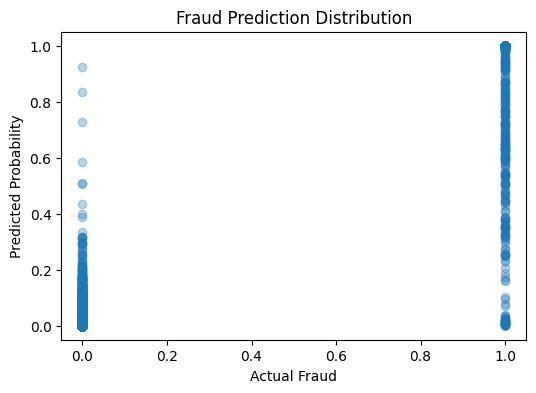

In [26]:
plt.figure(figsize=(6,4))

plt.scatter(
    df_stream["is_fraud"],
    df_stream["fraud_probability"],
    alpha=0.3
)

plt.xlabel("Actual Fraud")

plt.ylabel("Predicted Probability")

plt.title("Fraud Prediction Distribution")

plt.show()

In [27]:
total_txn = len(df_stream)

fraud_detected = df_stream["fraud_pred"].sum()

actual_fraud = df_stream["is_fraud"].sum()

print("Total Transactions:", total_txn)
print("Actual Fraud:", actual_fraud)
print("Detected Fraud:", fraud_detected)

Total Transactions: 10000
Actual Fraud: 1026
Detected Fraud: 831
